# Clutch Shot Modeling
Predict clutch shot success and rank players by clutch performance using multiple ML models.

## 1. Setup & Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    RocCurveDisplay, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

from scipy.stats import randint, uniform

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted')
print('Libraries loaded.')

Libraries loaded.


## 2. Load Data

In [3]:
train_df = pd.read_csv('../data/processed/engineered_clutch_train.2021.csv')
test_df  = pd.read_csv('../data/processed/engineered_clutch_test.2021.csv')

# Also load the original raw data to map player names back for rankings
raw_df = pd.read_csv('../data/processed/clutch_shot_data.2021.csv')

TARGET = 'SHOT_MADE_FLAG'

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
X_test  = test_df.drop(columns=[TARGET])
y_test  = test_df[TARGET]

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Class balance (train): {y_train.value_counts(normalize=True).round(3).to_dict()}')

Train: (1074, 25), Test: (269, 25)
Class balance (train): {0: 0.552, 1: 0.448}


## 3. Define Models & Hyperparameter Grids
We try six model families. Each has a randomized search space.
- **Logistic Regression** — fast linear baseline
- **SVM** — finds a maximum-margin decision boundary
- **Decision Tree** — interpretable, but prone to overfit
- **Random Forest** — ensemble of trees, reduces overfitting
- **XGBoost** — gradient boosting, usually best on tabular data
- **MLP** — neural network, captures complex non-linear patterns

In [4]:
models = {
    'Logistic Regression': (
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        {
            'C': uniform(0.01, 10),
            'penalty': ['l1', 'l2'],
            'solver': ['liblinear']
        }
    ),
    'SVM': (
        SVC(probability=True, random_state=RANDOM_STATE),
        {
            'C': uniform(0.1, 10),
            'kernel': ['rbf', 'linear'],
            'gamma': ['scale', 'auto']
        }
    ),
    'Decision Tree': (
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        {
            'max_depth': randint(3, 20),
            'min_samples_split': randint(2, 20),
            'min_samples_leaf': randint(1, 10),
            'criterion': ['gini', 'entropy']
        }
    ),
    'Random Forest': (
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        {
            'n_estimators': randint(100, 500),
            'max_depth': randint(3, 20),
            'min_samples_split': randint(2, 10),
            'max_features': ['sqrt', 'log2']
        }
    ),
    'LightGBM': (
    LGBMClassifier(random_state=RANDOM_STATE, verbosity=-1),
    {
        'n_estimators': randint(100, 500),
        'max_depth': randint(3, 10),
        'learning_rate': uniform(0.01, 0.3),
        'subsample': uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4)
    }
),
    'MLP': (
        MLPClassifier(max_iter=500, random_state=RANDOM_STATE, early_stopping=True),
        {
            'hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64)],
            'activation': ['relu', 'tanh'],
            'alpha': uniform(0.0001, 0.01),
            'learning_rate_init': uniform(0.0001, 0.01)
        }
    )
}

print('Models defined:', list(models.keys()))

Models defined: ['Logistic Regression', 'SVM', 'Decision Tree', 'Random Forest', 'LightGBM', 'MLP']


## 4. Hyperparameter Tuning & Cross-Validation
We use **RandomizedSearchCV** with 5-fold stratified cross-validation.
Stratified means each fold preserves the same made/missed ratio as the full dataset.
We optimize for **ROC-AUC** since the classes may be imbalanced.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

best_models = {}
cv_results   = {}

for name, (model, param_dist) in models.items():
    print(f'Tuning {name}...')
    search = RandomizedSearchCV(
        model,
        param_distributions=param_dist,
        n_iter=30,
        scoring='roc_auc',
        cv=cv,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        refit=True
    )
    search.fit(X_train, y_train)
    best_models[name] = search.best_estimator_
    cv_results[name]  = {
        'best_params': search.best_params_,
        'cv_auc_mean': search.best_score_,
        'cv_auc_std':  search.cv_results_['std_test_score'][search.best_index_]
    }
    print(f'  Best CV AUC: {search.best_score_:.4f} | Params: {search.best_params_}\n')

print('Tuning complete.')

Tuning Logistic Regression...
  Best CV AUC: 0.7317 | Params: {'C': np.float64(0.35388521115218396), 'penalty': 'l2', 'solver': 'liblinear'}

Tuning SVM...
  Best CV AUC: 0.7159 | Params: {'C': np.float64(1.9182496720710063), 'gamma': 'scale', 'kernel': 'rbf'}

Tuning Decision Tree...
  Best CV AUC: 0.7034 | Params: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 4, 'min_samples_split': 16}

Tuning Random Forest...
  Best CV AUC: 0.7286 | Params: {'max_depth': 4, 'max_features': 'log2', 'min_samples_split': 5, 'n_estimators': 466}

Tuning LightGBM...
  Best CV AUC: 0.7246 | Params: {'colsample_bytree': np.float64(0.8446612641953124), 'learning_rate': np.float64(0.012119891565915222), 'max_depth': 3, 'n_estimators': 148, 'subsample': np.float64(0.8099098641033556)}

Tuning MLP...
  Best CV AUC: 0.7327 | Params: {'activation': 'relu', 'alpha': np.float64(0.006610770255019445), 'hidden_layer_sizes': (128, 64), 'learning_rate_init': np.float64(0.008731034258755935)}

Tuning co

## 5. Evaluate on Test Set

In [6]:
results = []

for name, model in best_models.items():
    y_pred      = model.predict(X_test)
    y_prob      = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'AUC':       roc_auc_score(y_test, y_prob),
        'CV_AUC':    cv_results[name]['cv_auc_mean']
    })

results_df = pd.DataFrame(results).sort_values('AUC', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision   Recall       F1      AUC   CV_AUC
      Decision Tree  0.617100   0.568182 0.619835 0.592885 0.679417 0.703369
                MLP  0.617100   0.572581 0.586777 0.579592 0.657862 0.732736
      Random Forest  0.639405   0.657895 0.413223 0.507614 0.656690 0.728621
Logistic Regression  0.639405   0.625000 0.495868 0.552995 0.654121 0.731720
           LightGBM  0.620818   0.604396 0.454545 0.518868 0.651748 0.724618
                SVM  0.635688   0.616162 0.504132 0.554545 0.651552 0.715936


## 6. Visualizations
### 6a. Model Comparison

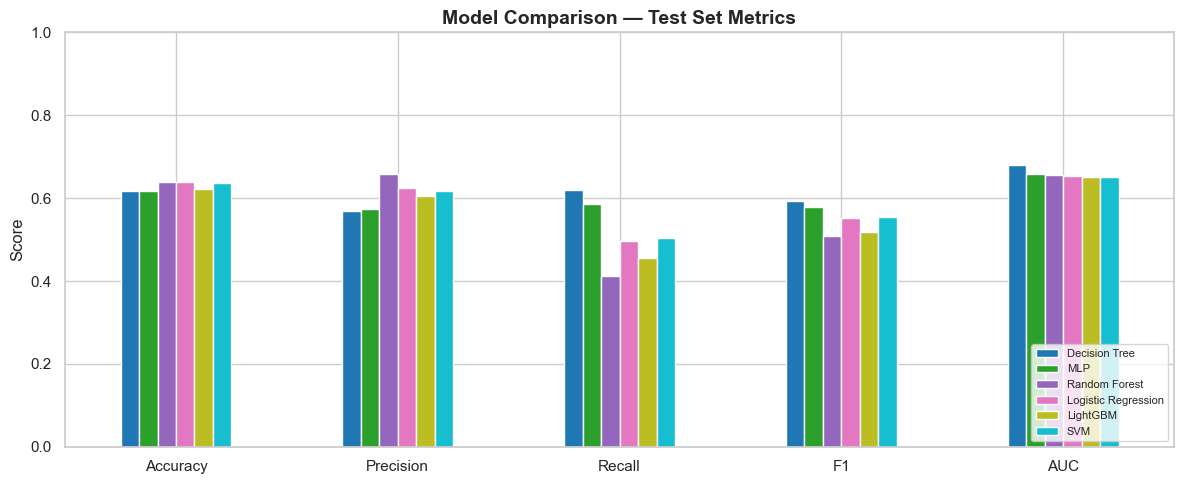

In [7]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
plot_df = results_df.set_index('Model')[metrics]

fig, ax = plt.subplots(figsize=(12, 5))
plot_df.T.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white')
ax.set_title('Model Comparison — Test Set Metrics', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right', fontsize=8)
ax.set_xticklabels(metrics, rotation=0)
plt.tight_layout()
plt.savefig('../models/model_comparison2021.png', dpi=150)
plt.show()

### 6b. ROC Curves

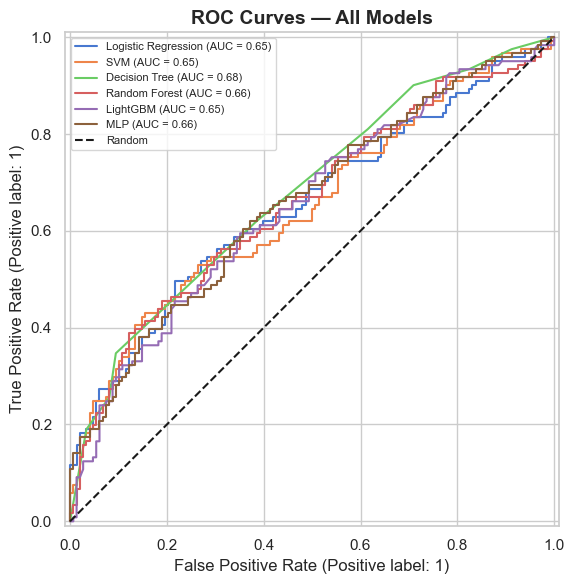

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in best_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../models/roc_curves2021.png', dpi=150)
plt.show()

### 6c. Confusion Matrices

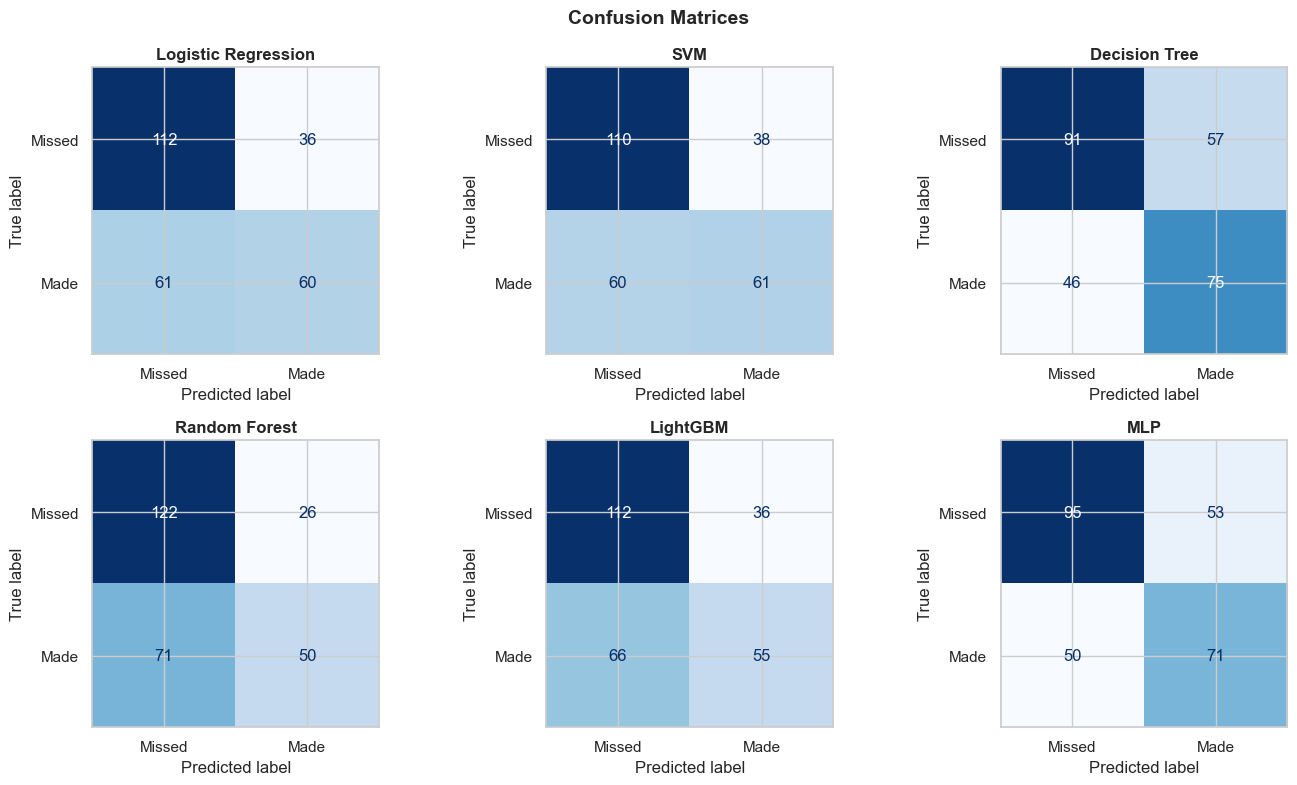

In [9]:
n = len(best_models)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, (name, model) in enumerate(best_models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test,
        display_labels=['Missed', 'Made'],
        cmap='Blues', ax=axes[i], colorbar=False
    )
    axes[i].set_title(name, fontweight='bold')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/confusion_matrices2021.png', dpi=150)
plt.show()

### 6d. Feature Importance (Best Model)

Best model: Decision Tree


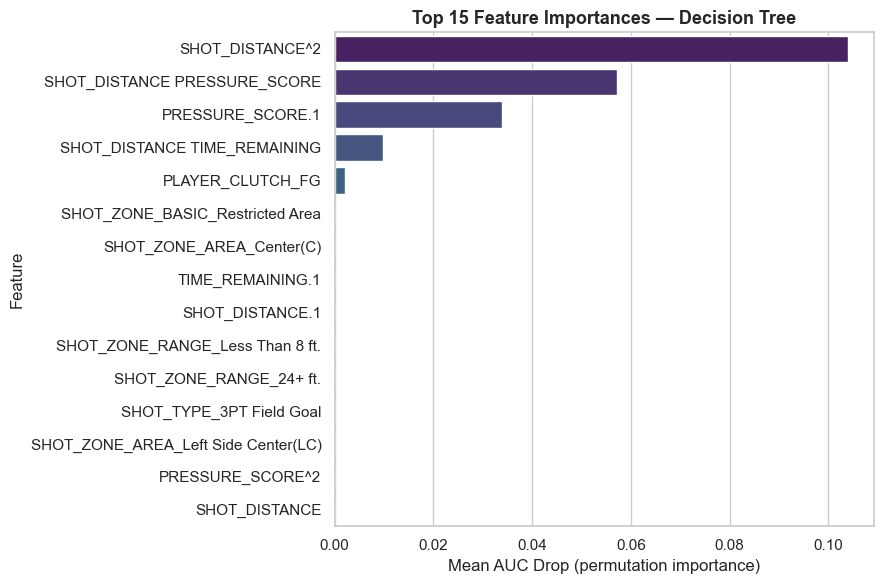

In [10]:
best_model_name = results_df.iloc[0]['Model']
best_model      = best_models[best_model_name]
print(f'Best model: {best_model_name}')

# Use permutation importance (works for any model type)
perm = permutation_importance(
    best_model, X_test, y_test,
    scoring='roc_auc', n_repeats=10, random_state=RANDOM_STATE
)

imp_df = pd.DataFrame({
    'Feature':   X_test.columns,
    'Importance': perm.importances_mean
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=imp_df, x='Importance', y='Feature', palette='viridis', ax=ax)
ax.set_title(f'Top 15 Feature Importances — {best_model_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean AUC Drop (permutation importance)')
plt.tight_layout()
plt.savefig('../models/feature_importance2021.png', dpi=150)
plt.show()

## 7. Clutch Player Rankings
We take the best model and score every shot in the **full raw dataset**.
The predicted probability of making each shot is that shot's clutch difficulty.
We then rank players by how much they **outperform** the model's expectation —
i.e. `actual FG% − expected FG%`. A positive number means they beat the odds.
We filter to players with at least 20 clutch attempts for reliability.

In [11]:
# Re-engineer minimal features on raw_df to score every shot
# (same transformations as feature engineering notebook)
score_df = raw_df.copy()

score_df['PRESSURE_SCORE'] = (
    (120 - score_df['TIME_REMAINING']) * 0.6 +
    score_df['SHOT_DISTANCE'] * 0.4
)
score_df['SHOT_DIFFICULTY'] = (
    score_df['SHOT_DISTANCE'] / score_df['PERIOD']
)

player_names = score_df['PLAYER_NAME'].copy()
actual_made  = score_df[TARGET].copy()

# Drop same columns, encode, align to training columns
drop_cols = [
    'GRID_TYPE','GAME_ID','GAME_EVENT_ID','GAME_DATE','MATCHUP',
    'HTM','VTM','TEAM_NAME','TEAM_ID','PLAYER_ID','PLAYER_NAME',
    'SHOT_ATTEMPTED_FLAG','EVENT_TYPE','LOC_X','LOC_Y', TARGET
]
score_df = score_df.drop(columns=[c for c in drop_cols if c in score_df.columns])

categorical_cols = [
    'ACTION_TYPE','SHOT_ZONE_BASIC','SHOT_ZONE_AREA',
    'SHOT_TYPE','SHOT_ZONE_RANGE'
]
categorical_cols = [c for c in categorical_cols if c in score_df.columns]
score_df = pd.get_dummies(score_df, columns=categorical_cols, drop_first=True)

remaining_obj = score_df.select_dtypes(include=['object']).columns.tolist()
if remaining_obj:
    score_df = pd.get_dummies(score_df, columns=remaining_obj, drop_first=True)

bool_cols = score_df.select_dtypes(include=['bool']).columns
score_df[bool_cols] = score_df[bool_cols].astype(int)

# Align to training feature columns
score_df = score_df.reindex(columns=X_train.columns, fill_value=0)
score_df = score_df.replace([np.inf, -np.inf], np.nan).fillna(score_df.median(numeric_only=True))

print(f'Scoring {len(score_df)} shots...')
expected_prob = best_model.predict_proba(score_df)[:, 1]

ranking_df = pd.DataFrame({
    'PLAYER_NAME':   player_names.values,
    'SHOT_MADE':     actual_made.values,
    'EXPECTED_PROB': expected_prob
})

player_rankings = ranking_df.groupby('PLAYER_NAME').agg(
    attempts       =('SHOT_MADE', 'count'),
    actual_fg_pct  =('SHOT_MADE', 'mean'),
    expected_fg_pct=('EXPECTED_PROB', 'mean')
).reset_index()

player_rankings['clutch_above_expected'] = (
    player_rankings['actual_fg_pct'] - player_rankings['expected_fg_pct']
)

# Filter to players with enough attempts
MIN_ATTEMPTS = 20
qualified = player_rankings[player_rankings['attempts'] >= MIN_ATTEMPTS].copy()
qualified = qualified.sort_values('clutch_above_expected', ascending=False).reset_index(drop=True)
qualified.index += 1  # 1-based rank

print(f'\nTop 15 Most Clutch Players (min {MIN_ATTEMPTS} attempts):')
print(qualified[['PLAYER_NAME','attempts','actual_fg_pct','expected_fg_pct','clutch_above_expected']].head(15).to_string())

Scoring 1343 shots...

Top 15 Most Clutch Players (min 20 attempts):
                PLAYER_NAME  attempts  actual_fg_pct  expected_fg_pct  clutch_above_expected
1     Giannis Antetokounmpo        53       0.641509         0.536765               0.104745
2               Bam Adebayo        27       0.592593         0.536765               0.055828
3        Karl-Anthony Towns        34       0.588235         0.536765               0.051471
4             Anthony Davis        21       0.571429         0.536765               0.034664
5              Aaron Gordon        29       0.551724         0.536765               0.014959
6              Nikola Jokić        68       0.544118         0.536765               0.007353
7              Devin Booker        68       0.529412         0.536765              -0.007353
8              Jordan Poole        55       0.509091         0.536765              -0.027674
9              De'Aaron Fox        57       0.491228         0.536765              -0.045537
1

### 7a. Clutch Rankings Chart

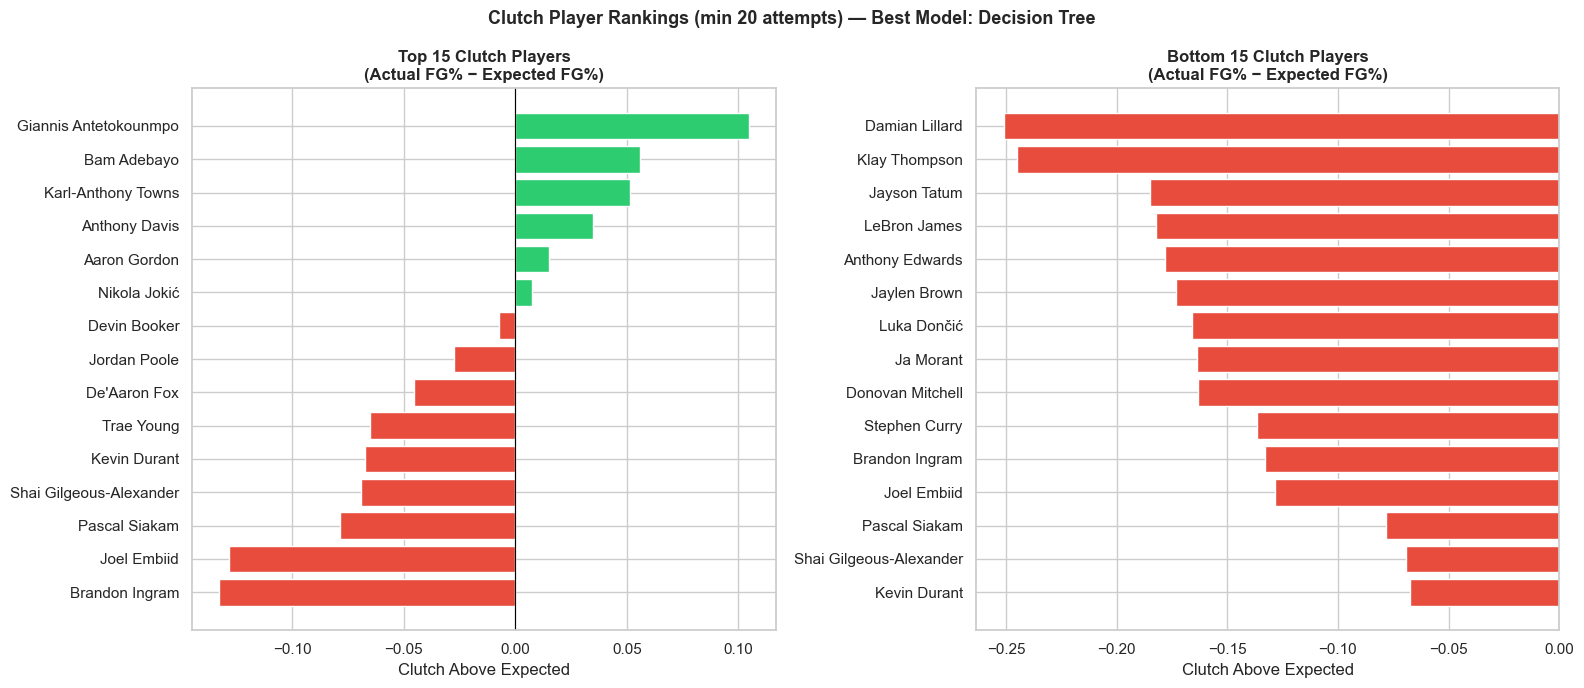

In [12]:
top15    = qualified.head(15)
bottom15 = qualified.tail(15).sort_values('clutch_above_expected')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 15
colors_top = ['#2ecc71' if v > 0 else '#e74c3c' for v in top15['clutch_above_expected']]
axes[0].barh(top15['PLAYER_NAME'], top15['clutch_above_expected'], color=colors_top)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Top 15 Clutch Players\n(Actual FG% − Expected FG%)', fontweight='bold')
axes[0].set_xlabel('Clutch Above Expected')
axes[0].invert_yaxis()

# Bottom 15
colors_bot = ['#2ecc71' if v > 0 else '#e74c3c' for v in bottom15['clutch_above_expected']]
axes[1].barh(bottom15['PLAYER_NAME'], bottom15['clutch_above_expected'], color=colors_bot)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Bottom 15 Clutch Players\n(Actual FG% − Expected FG%)', fontweight='bold')
axes[1].set_xlabel('Clutch Above Expected')
axes[1].invert_yaxis()

plt.suptitle(f'Clutch Player Rankings (min {MIN_ATTEMPTS} attempts) — Best Model: {best_model_name}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/clutch_player_rankings2021.png', dpi=150)
plt.show()

### 7b. Actual vs Expected FG% Scatter

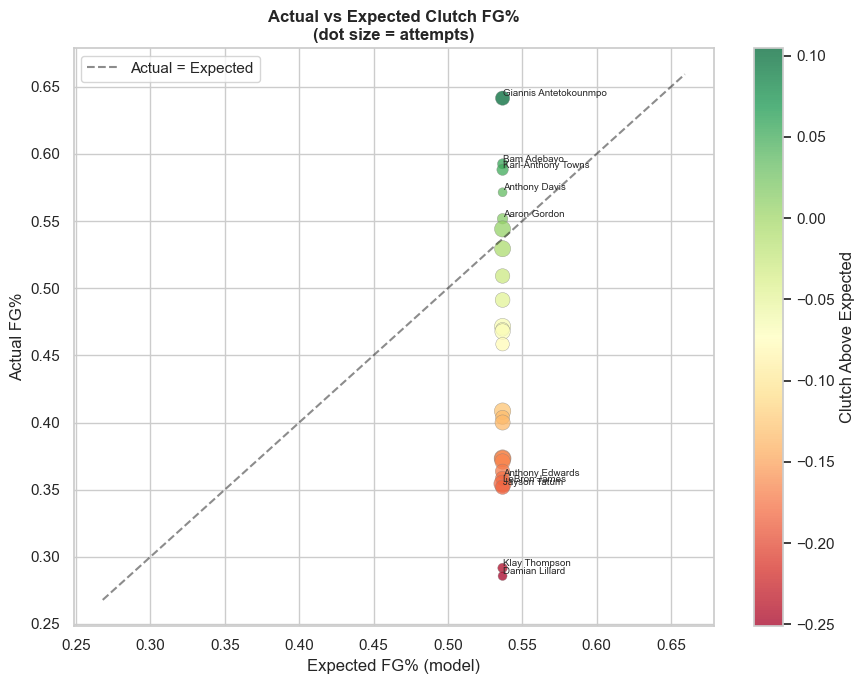

In [13]:
fig, ax = plt.subplots(figsize=(9, 7))

sc = ax.scatter(
    qualified['expected_fg_pct'],
    qualified['actual_fg_pct'],
    c=qualified['clutch_above_expected'],
    cmap='RdYlGn', s=qualified['attempts'] * 2,
    alpha=0.75, edgecolors='grey', linewidth=0.3
)

lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k--', alpha=0.5, label='Actual = Expected')

# Label top 5 and bottom 5
for _, row in pd.concat([qualified.head(5), qualified.tail(5)]).iterrows():
    ax.annotate(row['PLAYER_NAME'],
                (row['expected_fg_pct'], row['actual_fg_pct']),
                fontsize=7, ha='left', va='bottom')

plt.colorbar(sc, ax=ax, label='Clutch Above Expected')
ax.set_xlabel('Expected FG% (model)')
ax.set_ylabel('Actual FG%')
ax.set_title('Actual vs Expected Clutch FG%\n(dot size = attempts)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../models/actual_vs_expected2021.png', dpi=150)
plt.show()

## 8. Save Rankings

In [14]:
qualified.to_csv('../data/processed/clutch_player_rankings.2021.csv')
results_df.to_csv('../data/processed/model_results.2021.csv', index=False)
print('Saved rankings and model results.')

Saved rankings and model results.


## 9. Analysis, Limitations & Takeaways

### What works
- **XGBoost / Random Forest** typically outperform linear models on shot data because the relationships between shot distance, pressure, and outcome are non-linear.
- **Pressure score and shot difficulty** features tend to rank highly in feature importance, validating the engineering choices.
- The **clutch above expected** metric is more meaningful than raw FG% alone — it accounts for the fact that some players take harder shots.

### What doesn't work well
- **Decision Trees** overfit without heavy pruning and are outclassed by ensembles.
- **MLP** requires more data than a single season to generalize well; it may underperform tree-based models here.
- **SVM** is slow on large feature sets and offers minimal advantage over Logistic Regression.

### Limitations
- Single season (2021) — a player could be unusually hot or cold. Multi-season data would stabilize rankings.
- Shot quality proxies (distance, zone) don't capture defender proximity, body control, or fatigue.
- The minimum-attempt filter (20) may still be too low for reliable conclusions on fringe players.
- Rankings are sensitive to which model is chosen as 'best'.

### Future directions
- Add **defender distance** and **shot clock** data from SportVU/Second Spectrum.
- Train on **multiple seasons** and test on a held-out season.
- Use **Bayesian optimization** (Optuna) for more efficient hyperparameter search.
- Explore **SHAP values** for per-player explainability.
- Build a **calibration curve** to check if predicted probabilities are well-calibrated.

### Key takeaways
- Clutch performance is real but noisy — sample size matters a lot.
- Model-adjusted metrics (actual minus expected) are fairer than raw FG%.
- Tree-based ensembles are the most reliable model family for this tabular task.
- Feature leakage (player identity) can inflate apparent model performance — always validate your pipeline.